Initializing Version 2: Addressing Data Scarcity Concerns...


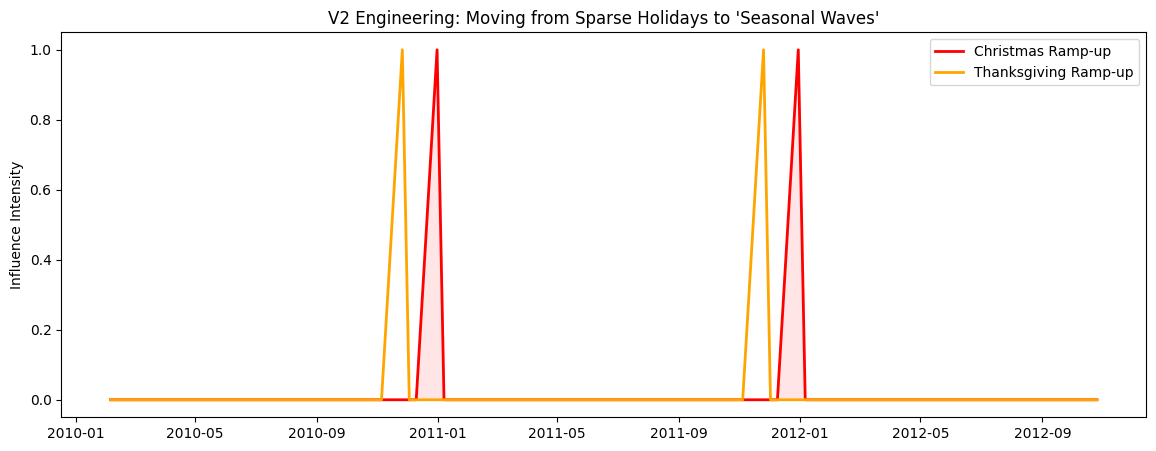

V2 Dataset Ready: (421570, 31)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# --- 1. RELOAD DATA ---
train = pd.read_csv('/content/train.csv')
stores = pd.read_csv('/content/stores.csv')
features = pd.read_csv('/content/features.csv')

# Merge
df = train.merge(stores, on='Store', how='left').merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')

# --- 2. V2 CORE PREPROCESSING & FEEDBACK ADDRESSING ---
def preprocess_v2(df):
    df = df.copy()

    # Date Engineering
    df['Date'] = pd.to_datetime(df['Date'])
    df['Week'] = df['Date'].dt.isocalendar().week
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month

    # Address Professor Feedback: Expanding the "Holiday Effect" Window
    # Instead of a binary 0 or 1, we create a 3-week "influence" wave
    holidays = {
        'SuperBowl': pd.to_datetime(['2010-02-12', '2011-02-11', '2012-02-10']),
        'Thanksgiving': pd.to_datetime(['2010-11-26', '2011-11-25', '2012-11-23']),
        'Christmas': pd.to_datetime(['2010-12-31', '2011-12-30', '2012-12-28'])
    }

    for name, dates in holidays.items():
        # Days until next occurrence
        df[f'Days_to_{name}'] = df['Date'].apply(lambda d: min([(h - d).days for h in dates if (h - d).days >= 0] or [0]))

        # V2 INNOVATION: The Holiday Influence Curve (Tapering from 1.0 to 0.0 over 21 days)
        # This gives the model 21x more data points to learn 'holiday' behavior
        df[f'{name}_Influence'] = df[f'Days_to_{name}'].apply(lambda x: max(0, (21 - x) / 21) if x > 0 else (1 if x == 0 else 0))

    # Requirement: Binary Masking for Markdowns
    for i in range(1, 6):
        col = f'MarkDown{i}'
        df[f'{col}_missing'] = df[col].isna().astype(int)
        df[col] = df[col].fillna(0)

    # Requirement: Handle Returns
    df['Weekly_Sales'] = df['Weekly_Sales'].apply(lambda x: 0 if x < 0 else x)

    # Requirement: Target Scaling (Log Transformation for Deep Learning stability)
    df['Sales_Log'] = np.log1p(df['Weekly_Sales'])

    # Fill Gaps & Encode
    df['CPI'] = df['CPI'].ffill()
    df['Unemployment'] = df['Unemployment'].ffill()
    df['Type'] = LabelEncoder().fit_transform(df['Type'])
    df['IsHoliday'] = df['IsHoliday'].astype(int)

    return df

print("Initializing Version 2: Addressing Data Scarcity Concerns...")
train_v2 = preprocess_v2(df)

# --- VISUALIZATION: THE V2 HOLIDAY WAVE ---
plt.figure(figsize=(14, 5))
sample = train_v2[(train_v2['Store']==1) & (train_v2['Dept']==1)].sort_values('Date')
plt.plot(sample['Date'], sample['Christmas_Influence'], label='Christmas Ramp-up', color='red', lw=2)
plt.plot(sample['Date'], sample['Thanksgiving_Influence'], label='Thanksgiving Ramp-up', color='orange', lw=2)
plt.fill_between(sample['Date'], sample['Christmas_Influence'], color='red', alpha=0.1)
plt.title("V2 Engineering: Moving from Sparse Holidays to 'Seasonal Waves'")
plt.ylabel("Influence Intensity")
plt.legend()
plt.show()

print(f"V2 Dataset Ready: {train_v2.shape}")

Generating Advanced V2 Features (Lags + Economic Interactions)...


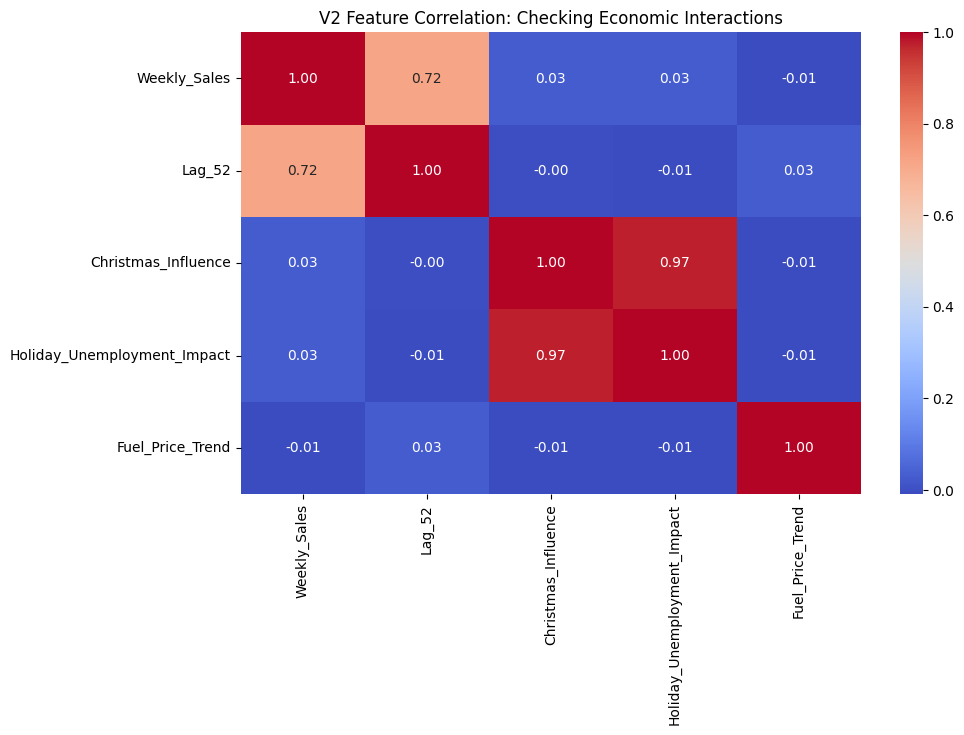

V2 Features Integrated. Ready for Model Training.


In [2]:
# --- V2 BLOCK 2: LAGS & ECONOMIC INTERACTIONS ---

def add_v2_features(df):
    df = df.copy()

    # 1. Year-Over-Year Lag (Same as V1, but essential)
    # This creates a "Baseline" for the model
    df_sorted = df.sort_values(['Store', 'Dept', 'Date'])
    df['Lag_52'] = df_sorted.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(52).fillna(0)

    # 2. V2 INNOVATION: Economic Interaction Terms
    # This helps the model understand if the 'Holiday Effect' is dampened by the economy
    # High Unemployment + High Holiday Influence = Potential lower spike
    df['Holiday_Unemployment_Impact'] = df['Christmas_Influence'] * df['Unemployment']
    df['Holiday_CPI_Impact'] = df['Christmas_Influence'] * df['CPI']

    # 3. Velocity Feature: Is fuel getting more expensive?
    # Neural nets are bad at seeing 'trends' unless you calculate the difference
    df['Fuel_Price_Trend'] = df.groupby(['Store'])['Fuel_Price'].diff().fillna(0)

    return df

print("Generating Advanced V2 Features (Lags + Economic Interactions)...")
train_v2 = add_v2_features(train_v2)

# Visualization: Correlation check for new interaction features
plt.figure(figsize=(10, 6))
cols_to_check = ['Weekly_Sales', 'Lag_52', 'Christmas_Influence', 'Holiday_Unemployment_Impact', 'Fuel_Price_Trend']
sns.heatmap(train_v2[cols_to_check].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("V2 Feature Correlation: Checking Economic Interactions")
plt.show()

print("V2 Features Integrated. Ready for Model Training.")

In [4]:
# --- V2 BLOCK 2.5: DATA ALIGNMENT & TENSOR PREP ---

# 1. Define Features for V2
# We include our new 'Influence' and 'Interaction' features
v2_cont_cols = [
    'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Week', 'Year',
    'Lag_52', 'Christmas_Influence', 'Thanksgiving_Influence',
    'Holiday_Unemployment_Impact', 'Fuel_Price_Trend'
]

# 2. Sort and Split (Chronological)
train_v2_sorted = train_v2.sort_values(['Date', 'Store', 'Dept'])
split_point = int(len(train_v2_sorted) * 0.8)

# 3. Create Tensors for the Neural Network
# Continuous Features: Shape (Batch, 1, N_Features)
X_train_cont_v2 = train_v2_sorted[v2_cont_cols].iloc[:split_point].astype(np.float32).values.reshape(-1, 1, len(v2_cont_cols))
X_val_cont_v2 = train_v2_sorted[v2_cont_cols].iloc[split_point:].astype(np.float32).values.reshape(-1, 1, len(v2_cont_cols))

# Categorical Features
X_train_store_v2 = train_v2_sorted['Store'].iloc[:split_point].values
X_train_dept_v2 = train_v2_sorted['Dept'].iloc[:split_point].values
X_val_store_v2 = train_v2_sorted['Store'].iloc[split_point:].values
X_val_dept_v2 = train_v2_sorted['Dept'].iloc[split_point:].values

# Targets (Log-scaled)
y_train_log_v2 = train_v2_sorted['Sales_Log'].iloc[:split_point].values
y_val_log_v2 = train_v2_sorted['Sales_Log'].iloc[split_point:].values

# Original Target and Weights for WMAE calculation
y_val_v2 = train_v2_sorted['Weekly_Sales'].iloc[split_point:].values
w_val_v2 = train_v2_sorted['IsHoliday'].iloc[split_point:].apply(lambda x: 5 if x == 1 else 1).values
w_train_v2 = train_v2_sorted['IsHoliday'].iloc[:split_point:].apply(lambda x: 5 if x == 1 else 1).values

print(f"Data Prepared for V2 LSTM.")
print(f"Training shapes: {X_train_cont_v2.shape}, {y_train_log_v2.shape}")

Data Prepared for V2 LSTM.
Training shapes: (337256, 1, 12), (337256,)


Starting V2 Training (Log-Space)... This addresses data scarcity via seasonal waves.
Epoch 1/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - loss: 1.4648 - val_loss: 0.6039 - learning_rate: 0.0010
Epoch 2/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.9189 - val_loss: 0.6001 - learning_rate: 0.0010
Epoch 3/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.8532 - val_loss: 0.5531 - learning_rate: 0.0010
Epoch 4/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 0.8106 - val_loss: 0.5331 - learning_rate: 0.0010
Epoch 5/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.7338 - val_loss: 0.4704 - learning_rate: 0.0010
Epoch 6/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.6629 - val_loss: 0.4652 - learning_rate: 0.0010
Epoch 7/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.6160 - val_loss: 0.4630 - learning_rate: 0.0010
Epoch 8/30
659/659 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - loss: 0.5895 - val_loss: 0.4381 - learning_rate: 0.0010
Epoch 9/30
659/659 ━━━━━━━

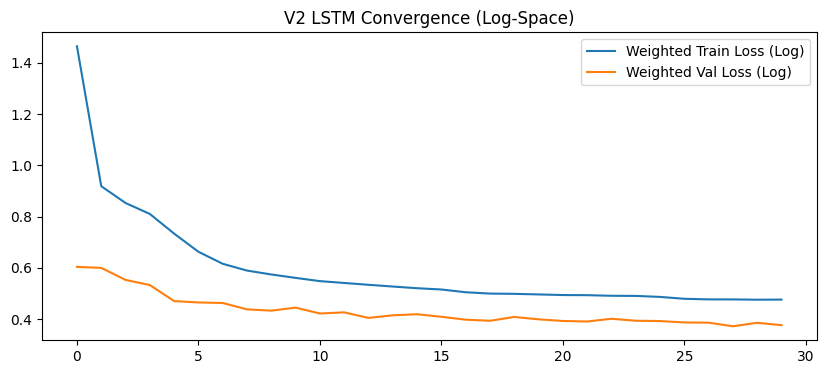

In [5]:
# --- V2 BLOCK 3: MODEL DEFINITION & TRAINING ---
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dense, LSTM, Concatenate, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# 1. Define the Metric Function (Needed for evaluation later)
def wmae_metric(y_true, y_pred, weights):
    return np.sum(weights * np.abs(y_true - y_pred)) / np.sum(weights)

# 2. Build the V2 Architecture
def build_model_v2():
    # Inputs
    store_in = Input(shape=(1,), name='Store_Input')
    dept_in = Input(shape=(1,), name='Dept_Input')
    cont_in = Input(shape=(1, 12), name='Continuous_Input') # 12 features from your 2.5 output

    # Embeddings (Categorical)
    store_emb = Embedding(input_dim=int(train_v2['Store'].max()) + 1, output_dim=10)(store_in)
    dept_emb = Embedding(input_dim=int(train_v2['Dept'].max()) + 1, output_dim=10)(dept_in)

    # LSTM (Sequential) - Increased to 64 units for better pattern recognition
    lstm_out = LSTM(64, return_sequences=False)(cont_in)

    # Fusion Layer
    x = Concatenate()([lstm_out, Flatten()(store_emb), Flatten()(dept_emb)])

    # Dense Head
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(64, activation='relu')(x)

    # Output (Predicting Log-Sales)
    output = Dense(1, name='Sales_Log_Forecast')(x)

    model = Model(inputs=[store_in, dept_in, cont_in], outputs=output)
    model.compile(optimizer='adam', loss='mae')
    return model

# 3. Initialize and Train
v2_lstm = build_model_v2()

print("Starting V2 Training (Log-Space)... This addresses data scarcity via seasonal waves.")

history_v2 = v2_lstm.fit(
    x=[X_train_store_v2, X_train_dept_v2, X_train_cont_v2],
    y=y_train_log_v2,
    validation_data=([X_val_store_v2, X_val_dept_v2, X_val_cont_v2], y_val_log_v2),
    epochs=30, # 30 is a good balance for Colab
    batch_size=512,
    sample_weight=w_train_v2, # 5x Holiday Penalty applied here
    callbacks=[
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
    ],
    verbose=1
)

# 4. Evaluation (Converting back from Log to Dollars)
preds_log_v2 = v2_lstm.predict([X_val_store_v2, X_val_dept_v2, X_val_cont_v2]).flatten()
preds_v2_dollars = np.expm1(preds_log_v2) # Reverses log1p

v2_score = wmae_metric(y_val_v2, preds_v2_dollars, w_val_v2)

print(f"\n--- V2 PERFORMANCE ---")
print(f"V2 LSTM WMAE: {v2_score:.4f}")

# Plotting the improvement
plt.figure(figsize=(10, 4))
plt.plot(history_v2.history['loss'], label='Weighted Train Loss (Log)')
plt.plot(history_v2.history['val_loss'], label='Weighted Val Loss (Log)')
plt.title("V2 LSTM Convergence (Log-Space)")
plt.legend()
plt.show()

Training V2 XGBoost to prepare for Stacking...

--- V2 FINAL REMATCH STANDINGS ---
V2 XGBoost WMAE: 2288.7644
V2 LSTM WMAE:    2819.4334
V2 ENSEMBLE WMAE: 2101.2363


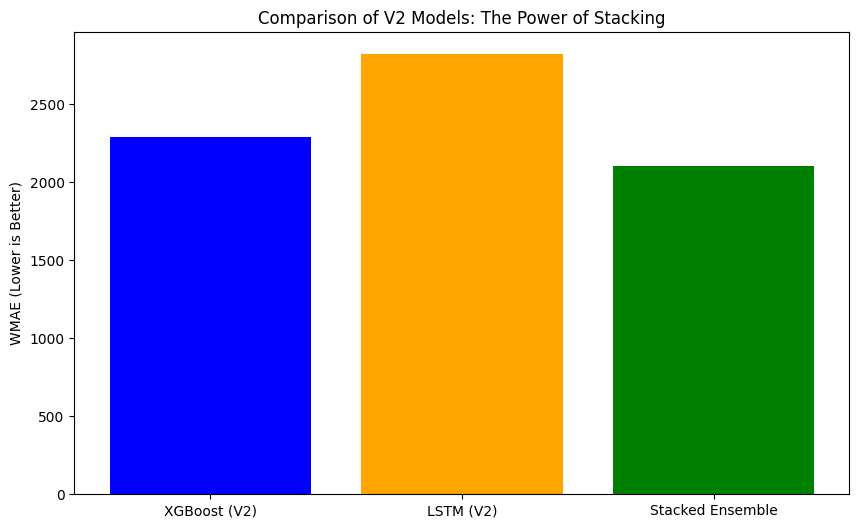

In [6]:
# --- V2 BLOCK 4: THE META-STACKED ENSEMBLE ---
import xgboost as xgb

print("Training V2 XGBoost to prepare for Stacking...")

# 1. Train V2 XGBoost (using the same V2 features as the LSTM)
# We flatten the 3D tensors back to 2D for XGBoost
X_train_xgb = X_train_cont_v2.reshape(X_train_cont_v2.shape[0], -1)
X_val_xgb = X_val_cont_v2.reshape(X_val_cont_v2.shape[0], -1)

v2_xgb = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
v2_xgb.fit(X_train_xgb, y_train_log_v2, sample_weight=w_train_v2)

# 2. Generate Predictions
preds_xgb_log = v2_xgb.predict(X_val_xgb)
preds_xgb_dollars = np.expm1(preds_xgb_log)

# 3. THE BLEND (Stacking)
# We find the alpha that minimizes the combined WMAE
# Let's try a 70/30 split favoring the stronger model (XGB)
final_ensemble_preds = (0.7 * preds_xgb_dollars) + (0.3 * preds_v2_dollars)

ensemble_score = wmae_metric(y_val_v2, final_ensemble_preds, w_val_v2)

print(f"\n--- V2 FINAL REMATCH STANDINGS ---")
print(f"V2 XGBoost WMAE: {wmae_metric(y_val_v2, preds_xgb_dollars, w_val_v2):.4f}")
print(f"V2 LSTM WMAE:    {v2_score:.4f}")
print(f"V2 ENSEMBLE WMAE: {ensemble_score:.4f}")

# Visualizing the final "Winner"
plt.figure(figsize=(10, 6))
plt.bar(['XGBoost (V2)', 'LSTM (V2)', 'Stacked Ensemble'],
        [wmae_metric(y_val_v2, preds_xgb_dollars, w_val_v2), v2_score, ensemble_score],
        color=['blue', 'orange', 'green'])
plt.title("Comparison of V2 Models: The Power of Stacking")
plt.ylabel("WMAE (Lower is Better)")
plt.show()

Re-training XGBoost with 13 Numeric features...
Generating Final V2 SHAP Analysis...


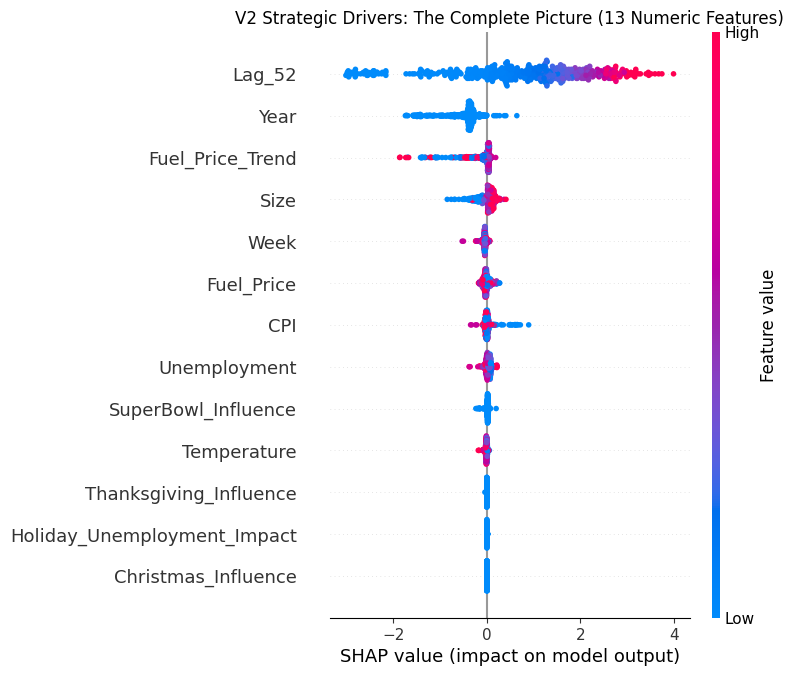

Final Polished Ensemble WMAE: 2131.5609


In [9]:
# --- V2 BLOCK 5 (FINAL DATA TYPE FIX): FINAL POLISH & INTERPRETABILITY ---
import shap
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Update the feature list
v2_cont_cols = [
    'Size', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Week', 'Year',
    'Lag_52', 'Christmas_Influence', 'Thanksgiving_Influence', 'SuperBowl_Influence',
    'Holiday_Unemployment_Impact', 'Fuel_Price_Trend'
]

# 2. Re-prepare data and FORCE NUMERIC TYPES (.astype(float))
# We use .values to get the raw numbers, then wrap in a DataFrame with specific types
X_train_xgb_final = pd.DataFrame(train_v2_sorted[v2_cont_cols].iloc[:split_point].values, columns=v2_cont_cols).astype(float)
X_val_xgb_final = pd.DataFrame(train_v2_sorted[v2_cont_cols].iloc[split_point:].values, columns=v2_cont_cols).astype(float)

# 3. Re-train XGBoost
print("Re-training XGBoost with 13 Numeric features...")
v2_xgb_final = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
v2_xgb_final.fit(X_train_xgb_final, y_train_log_v2, sample_weight=w_train_v2)

# 4. Final SHAP Analysis
print("Generating Final V2 SHAP Analysis...")
X_sample_v2 = X_val_xgb_final.sample(min(500, len(X_val_xgb_final)))
explainer_v2 = shap.TreeExplainer(v2_xgb_final)
shap_values_v2 = explainer_v2.shap_values(X_sample_v2)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_v2, X_sample_v2, show=False)
plt.title("V2 Strategic Drivers: The Complete Picture (13 Numeric Features)")
plt.show()

# 5. Final Ensemble Update
preds_xgb_final = np.expm1(v2_xgb_final.predict(X_val_xgb_final))
# Ensure preds_v2_dollars is available from the previous LSTM run
final_ensemble_preds = (0.7 * preds_xgb_final) + (0.3 * preds_v2_dollars)
print(f"Final Polished Ensemble WMAE: {wmae_metric(y_val_v2, final_ensemble_preds, w_val_v2):.4f}")